In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
train_df=pd.read_csv('Heart disease train.csv')
test_df=pd.read_csv('Heart disease test.csv')
train_df.head()


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [22]:
train_df=train_df.drop('id',axis=1)
test_df=test_df.drop('id',axis=1)
train_df['Heart Disease'] = train_df['Heart Disease'].map({'Presence': 1, 'Absence': 0})
train_df=pd.get_dummies(train_df,columns=['Chest pain type','EKG results','Slope of ST'])
test_df=pd.get_dummies(test_df,columns=['Chest pain type','EKG results','Slope of ST'])
                                     

In [23]:
train_df.head()

,Age,Sex,BP,Cholesterol,FBS over 120,Max HR,Exercise angina,ST depression,Number of vessels fluro,Thallium,...,Chest pain type_1,Chest pain type_2,Chest pain type_3,Chest pain type_4,EKG results_0,EKG results_1,EKG results_2,Slope of ST_1,Slope of ST_2,Slope of ST_3
0,58,1,152,239,0,158,1,3.6,2,7,...,False,False,False,True,True,False,False,False,True,False
1,52,1,125,325,0,171,0,0.0,0,3,...,True,False,False,False,False,False,True,True,False,False
2,56,0,160,188,0,151,0,0.0,0,3,...,False,True,False,False,False,False,True,True,False,False
3,44,0,134,229,0,150,0,1.0,0,3,...,False,False,True,False,False,False,True,False,True,False
4,58,1,140,234,0,125,1,3.8,3,3,...,False,False,False,True,False,False,True,False,True,False


Age                        0
Sex                        0
BP                         0
Cholesterol                0
FBS over 120               0
Max HR                     0
Exercise angina            0
ST depression              0
Number of vessels fluro    0
Thallium                   0
Chest pain type_1          0
Chest pain type_2          0
Chest pain type_3          0
Chest pain type_4          0
EKG results_0              0
EKG results_1              0
EKG results_2              0
Slope of ST_1              0
Slope of ST_2              0
Slope of ST_3              0
Heart Disease              0
dtype: int64


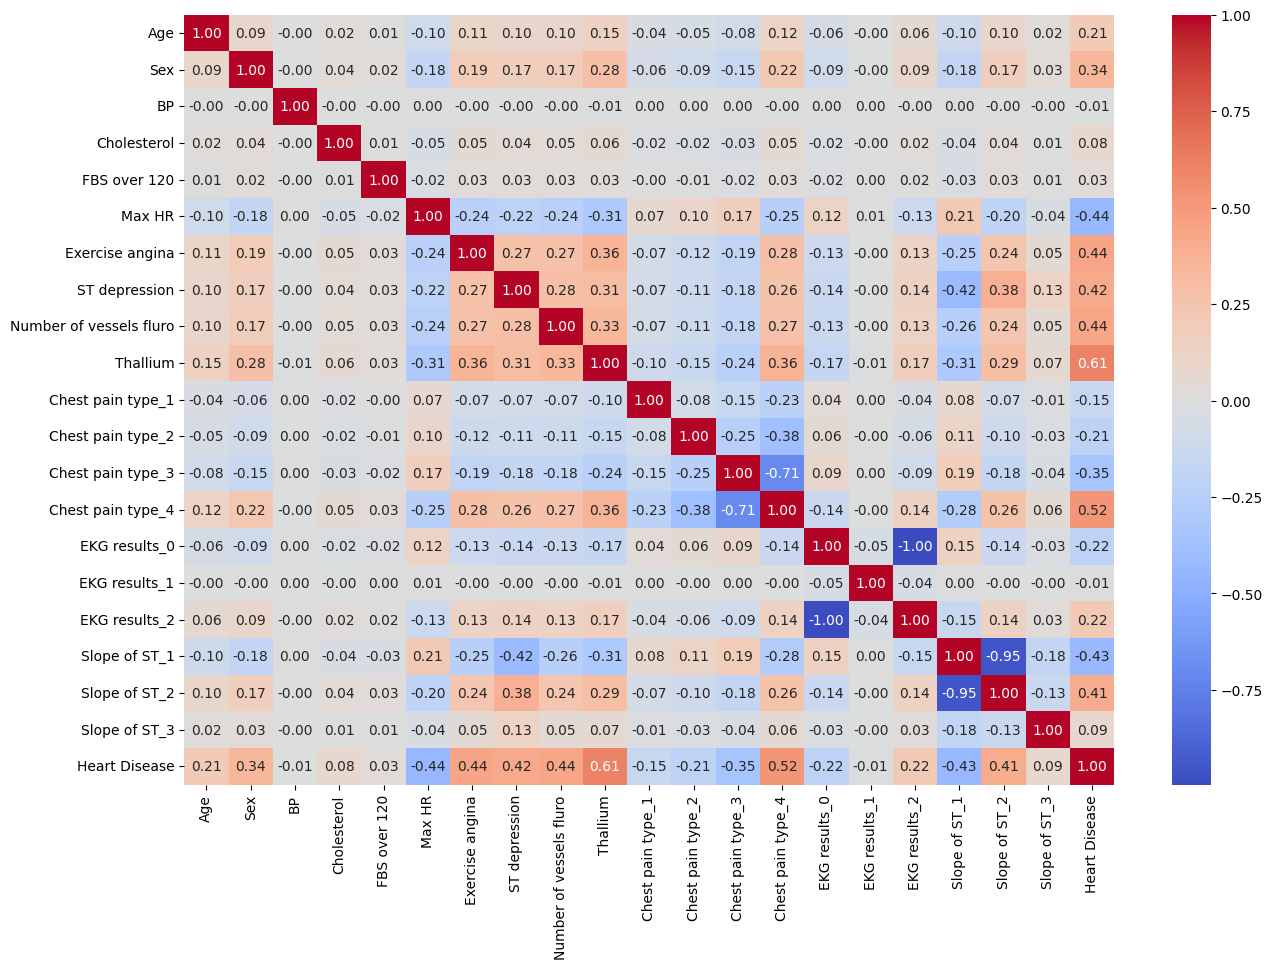

In [24]:
y_train=train_df['Heart Disease']
x_train=train_df.drop('Heart Disease', axis=1)
test_df=test_df.reindex(columns=x_train.columns, fill_value=0)

train_correlation=pd.concat([x_train,y_train],axis=1)
# 1. Check which columns have missing values
print(train_correlation.isnull().sum())

# 2. Fill missing values with the median (best for clinical data)
# We use median because it's less sensitive to outliers than mean
train_correlation = train_correlation.fillna(train_correlation.median())

# 3. NOW you can safely convert to int and run correlation
train_correlation = train_correlation.astype(int)
correlation_matrix = train_correlation.corr()

# 4. Plot again
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

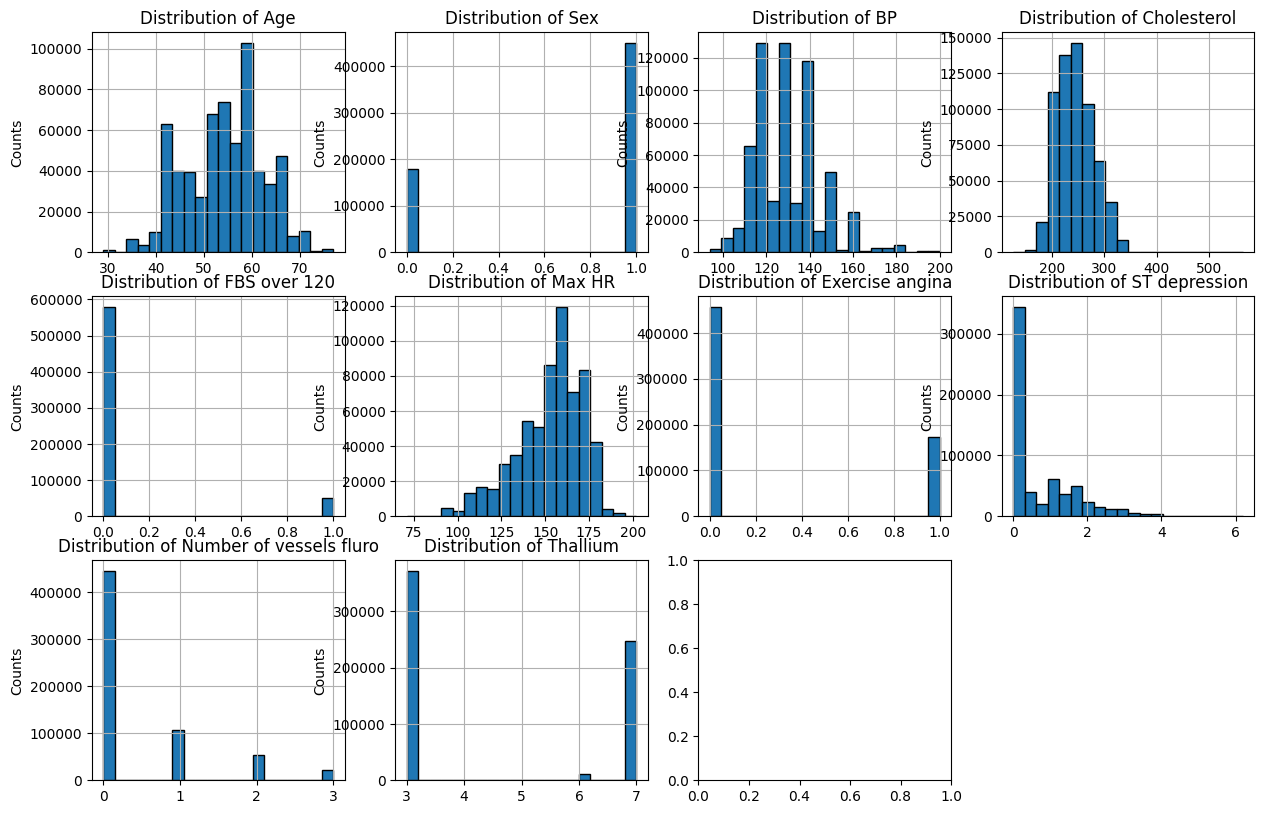

In [27]:
import matplotlib.pyplot as plt

# Use x_train.columns because it already excludes the target variable!
features = x_train.columns

# Set up a figure with a reasonable size
plt.figure(figsize=(15, 20))

for i, col in enumerate(features):
    plt.subplot(6, 4, i + 1) # Create a grid (adjust rows/cols as needed)
    
    # Plot the histogram for this specific feature
    # We use x_train[col] to ensure we match the features perfectly
    x_train[col].hist(bins=20, edgecolor='black')
    
    plt.title(f"Distribution of {col}")
    plt.ylabel("Counts")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
l_train_x,x_val,l_train_y,y_val=train_test_split(x_train,y_train,test_size=0.2,random_state=42)
l_train_x_scaled=scaler.fit_transform(l_train_x)
x_val_scaled=scaler.transform(x_val)
x_test_scaled=scaler.transform(test_df)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
model = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=5, random_state=42)
model.fit(l_train_x_scaled,l_train_y)
# 1. Get predictions for the training data
y_train_pred = model.predict(l_train_x_scaled)

# 2. Get predictions for the validation data
y_val_pred = model.predict(x_val_scaled)

# 3. Calculate accuracies correctly 
# We compare the true labels (y) to the predicted labels (y_pred)
train_accuracy = accuracy_score(l_train_y, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)

# 4. Print the comparison
print(f"Training Accuracy:   {train_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Training Accuracy:   87.69%
Validation Accuracy: 87.59%


In [31]:
final_predictions = model.predict(x_test_scaled)
original_test = pd.read_csv('Heart disease test.csv')
submission = pd.DataFrame({
    'id': original_test['id'],
    'Heart Disease': final_predictions
})

submission.to_csv('heart_disease_submission.csv', index=False)

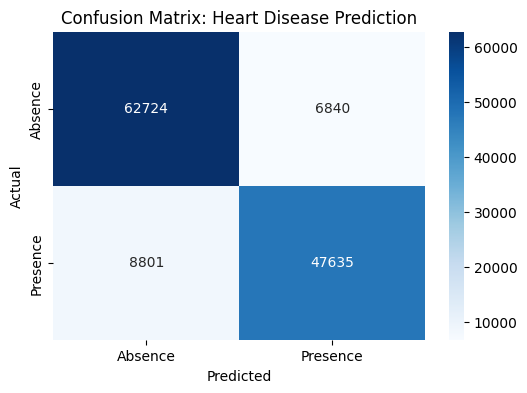

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Create the matrix
cm = confusion_matrix(y_val, y_val_pred)

# 2. Plot it
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Absence', 'Presence'], 
            yticklabels=['Absence', 'Presence'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Heart Disease Prediction')
plt.show()

In [30]:
submission.head()

,id,Heart Disease
0,630000,1
1,630001,0
2,630002,1
3,630003,0
4,630004,0


In [33]:
import os
print(os.getcwd())

C:\Users\saish
